[![Labellerr](https://storage.googleapis.com/labellerr-cdn/%200%20Labellerr%20template/notebook.webp)](https://www.labellerr.com)

# **Brand Logo Detection**

---

[![labellerr](https://img.shields.io/badge/Labellerr-BLOG-black.svg)](https://www.labellerr.com/blog/<BLOG_NAME>)
[![Youtube](https://img.shields.io/badge/Labellerr-YouTube-b31b1b.svg)](https://www.youtube.com/@Labellerr)
[![Github](https://img.shields.io/badge/Labellerr-GitHub-green.svg)](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)

## Project Overview

- Perform **zero-shot brand logo detection** using **Grounding DINO** — a state-of-the-art open-set object detector.
- No custom training or logo-specific dataset required; the model detects logos via **natural language text prompts**.
- Leverages a **Vision-Language model** that jointly understands image content and free-form text descriptions.
- Capable of detecting **multiple brand logos** in a single image with bounding boxes and confidence scores.
- Works across diverse image types — product photos, street scenes, event images, and more.

## Real-World Applications

- **Brand Monitoring & Social Media Listening:**
  - Automatically scan user-generated content across platforms to track logo visibility.
  - Detect unauthorized or unverified use of brand logos online.

- **Retail & Shelf Analytics:**
  - Monitor product placement, stock availability, and brand presence on store shelves.
  - Compare competitor brand visibility within the same retail space.

- **Sports Sponsorship & ROI Measurement:**
  - Track sponsor logo screen time and position during live broadcasts and recorded events.
  - Quantify brand exposure to help sponsors evaluate the value of their investment.

- **Counterfeit & Fraud Detection:**
  - Identify fake or tampered brand logos on products listed in online marketplaces.
  - Flag suspicious listings for further review by brand protection teams.

- **Advertising & Media Intelligence:**
  - Analyze brand logo appearances in print, digital ads, and video content.
  - Build automated pipelines for media auditing and competitive intelligence.

- **Logo Blurring for Unsponsored Marketing Removal:**
  - Automatically detect and blur brand logos in images and videos to remove unsponsored or unwanted marketing content.
  - Useful for content creators, broadcasters, and media companies who need to comply with sponsorship agreements by obscuring competitor or non-approved brand logos.
  - Enables privacy-preserving post-production workflows where visible trademarks must be redacted before publishing.


## Environment Setup & Importing Libraries

- `torch`, `torchvision` — Deep learning framework.
- `opencv-python`, `matplotlib`, `pillow` — Image processing & visualization.
- `supervision` — Simplifies handling detection outputs.
- `transformers`, `accelerate` — Load and run the Vision-Language model.


In [2]:
!pip install -q torch torchvision
!pip install -q opencv-python matplotlib pillow
!pip install -q supervision
!pip install -q transformers accelerate


[notice] A new release of pip is available: 24.3.1 -> 26.2
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.2
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.2
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.2
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [3]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

## Device Configuration & Model Imports

- Detects if a GPU (`cuda`) is available, otherwise defaults to `cpu`.
- **`AutoProcessor`** — Preprocesses images and text prompts for the model.
- **`AutoModelForZeroShotObjectDetection`** — Loads the zero-shot detection model.


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cpu


In [5]:
from transformers import AutoProcessor
from transformers import AutoModelForZeroShotObjectDetection

## Verifying Python Interpreter & Upgrading Core Packages

- Prints the active Python interpreter path to confirm the correct environment.
- Upgrades `transformers` and `accelerate` to their latest versions.


In [6]:
import sys
print(sys.executable)

c:\Users\msi msi\AppData\Local\Programs\Python\Python310\python.exe


In [7]:
%pip install -U transformers accelerate

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Loading the Grounding DINO Model

- Uses `IDEA-Research/grounding-dino-base` from Hugging Face.
- **Grounding DINO** detects objects from free-form text prompts — ideal for zero-shot logo detection.
- **`AutoProcessor`** — Tokenizes text and normalizes the input image.
- **`AutoModelForZeroShotObjectDetection`** — Runs detection and outputs bounding boxes with confidence scores.


In [8]:
model_id = "IDEA-Research/grounding-dino-base"

processor = AutoProcessor.from_pretrained(model_id)

model = AutoModelForZeroShotObjectDetection.from_pretrained(
    model_id
).to(device)

Loading weights:   0%|          | 0/1182 [00:00<?, ?it/s]

## Loading & Visualizing the Input Image

- Loads the test image (Adidas T-shirt) using `PIL`.
- Converts to `RGB` format as required by the model.
- Displays the raw image using `matplotlib` for a before/after comparison.


(-0.5, 1079.5, 1439.5, -0.5)

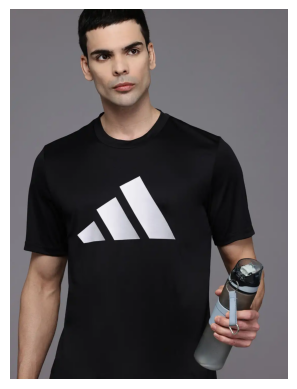

In [10]:
image = Image.open("504c6761-6d44-4db2-8994-ee73febc161e1731579747256-ADIDAS-Men-Tshirts-591731579746938-1.webp").convert("RGB")

plt.imshow(image)
plt.axis("off")

## Defining the Text Prompt

- The `text_prompt` is the natural language query passed to Grounding DINO to guide detection.
- `"logo."` tells the model to locate any visible logo in the image — no brand name needed.
- The **trailing period (`.`)** is required by Grounding DINO as a sentence terminator.
- Can be customized (e.g., `"adidas logo."`) for brand-specific detection.


In [76]:
text_prompt = "logo."

## Preprocessing & Running Inference

- **`processor(...)`** — Encodes the image and text prompt into tensors the model can consume.
- **`return_tensors="pt"`** — Returns PyTorch tensors; `.to(device)` moves them to GPU/CPU.
- **`torch.no_grad()`** — Disables gradient computation to save memory during inference.
- **`model(**inputs)`** — Runs the forward pass and returns raw detection outputs (logits & boxes).


In [77]:
inputs = processor(
    images=image,
    text=text_prompt,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

## Post-Processing Detection Outputs

- **`post_process_grounded_object_detection()`** — Converts raw model outputs into human-readable bounding boxes and labels.
- **`target_sizes=[image.size[::-1]]`** — Rescales boxes to match the original image dimensions (`height, width`).
- **`threshold=0.3`** — Filters out detections with confidence score below 30%; only high-confidence logos are kept.
- The `results` list contains the final bounding boxes, scores, and labels for each detected logo.


In [78]:
results = processor.post_process_grounded_object_detection(
    outputs=outputs,
    target_sizes=[image.size[::-1]],
    threshold=0.3
)

In [79]:
print(results[0].keys())

dict_keys(['scores', 'boxes', 'text_labels', 'labels'])


In [80]:
print(results[0]["boxes"])
print(results[0]["scores"])
print(results[0]["labels"])

tensor([[ 712.7058,   15.0559,  773.9536,   89.9079],
        [ 900.5073,  453.1491,  965.4688,  527.0650],
        [ 458.7184,    5.7257, 1164.4004,  895.0646]])
tensor([0.3074, 0.3085, 0.3815])
['logo', 'logo', 'logo']


## Visualizing Detection Results

- **`np.array(image).copy()`** — Converts the PIL image to a NumPy array for OpenCV drawing.
- **`boxes`, `scores`, `labels`** — Extracted from `results[0]` and moved to CPU as NumPy arrays.
- **`cv2.rectangle()`** — Draws a green bounding box around each detected logo.
- **`cv2.putText()`** — Overlays the label name and confidence score in blue above each box.
- **`plt.imshow()`** — Renders the annotated image for visual inspection of all detections.


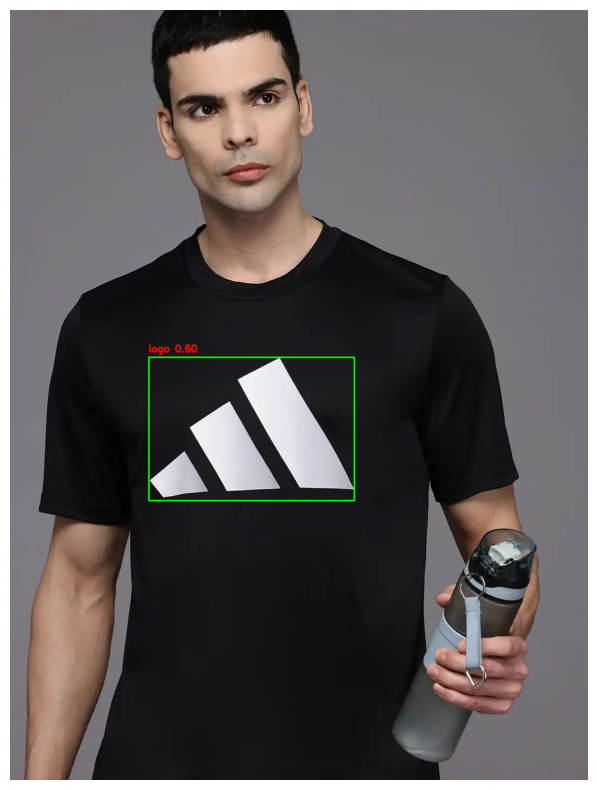

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_np = np.array(image).copy()

boxes = results[0]["boxes"].cpu().numpy()
scores = results[0]["scores"].cpu().numpy()
labels = results[0]["labels"]

for box, score, label in zip(boxes, scores, labels):

    x1, y1, x2, y2 = box.astype(int)

    cv2.rectangle(
        image_np,
        (x1, y1),
        (x2, y2),
        (0,255,0),
        2
    )

    cv2.putText(
        image_np,
        f"{label} {score:.2f}",
        (x1, y1-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255,0,0),
        2
    )

plt.figure(figsize=(10,10))
plt.imshow(image_np)
plt.axis("off")
plt.show()

## Logo Redaction via Gaussian Blur

- Demonstrates a practical use case: **automatically blurring/redacting brand logos** from images.
- **`padding = 15`** — Expands each bounding box slightly to ensure the full logo is covered.
- **`max()`/`min()` clipping** — Prevents the padded box from going out of image boundaries.
- **`roi = image_np[y1:y2, x1:x2]`** — Crops the detected logo region from the image.
- **`cv2.GaussianBlur(roi, (151,151), 80)`** — Applies a strong blur to anonymize the logo.
- The blurred region is written back into the original image, replacing the logo cleanly.


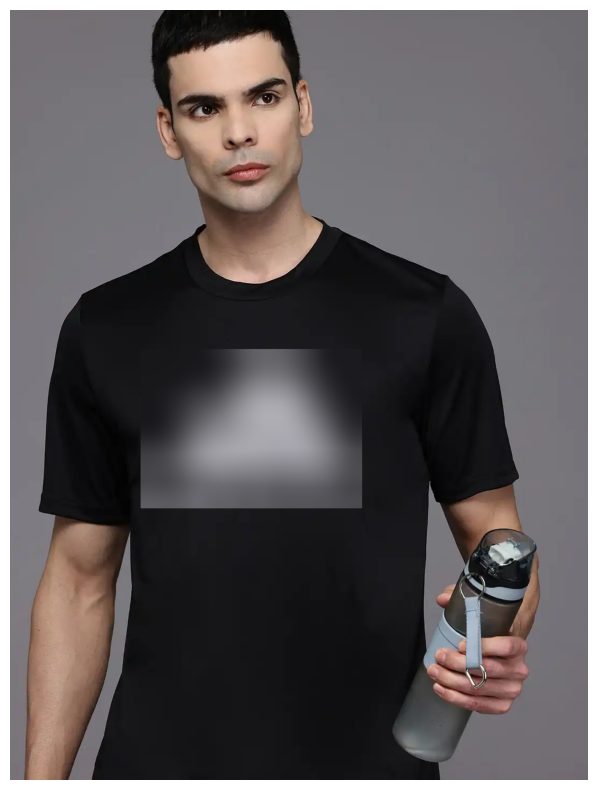

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Convert PIL image to numpy
image_np = np.array(image).copy()

# Loop through all detected logos
for box in results[0]["boxes"]:

    x1, y1, x2, y2 = box.cpu().numpy().astype(int)

    # Add some padding so the entire logo gets covered
    padding = 15

    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(image_np.shape[1], x2 + padding)
    y2 = min(image_np.shape[0], y2 + padding)

    # Crop the logo region
    roi = image_np[y1:y2, x1:x2]

    # Apply Gaussian Blur
    blurred_roi = cv2.GaussianBlur(roi, (151, 151), 80)

    # Replace the region
    image_np[y1:y2, x1:x2] = blurred_roi

# Display
plt.figure(figsize=(10,10))
plt.imshow(image_np)
plt.axis("off")
plt.show()

## Video Logo Redaction Pipeline

Extends the image-level logo blurring to a **full video pipeline** — detecting and redacting brand logos on every frame.

**Inputs & Config:**
- `video_path` / `output_path` — Source video and destination for the processed output.
- `text_prompt = "logo."` — Grounding DINO prompt to detect any logo in each frame.
- `BOX_THRESHOLD = 0.30` — Minimum confidence score to accept a detection.
- `PADDING = 15` — Extra pixels added around each box to fully cover the logo.

**Video I/O:**
- **`cv2.VideoCapture()`** — Reads the input video frame by frame.
- **`cv2.VideoWriter()`** — Writes processed frames to an `.mp4` output file at the same FPS and resolution.

**Per-Frame Processing:**
- Frame is converted **BGR → RGB** for PIL/model compatibility, then back **RGB → BGR** for writing.
- Each frame is passed through **Grounding DINO** for logo detection.
- Detected logo regions are cropped, blurred with **Gaussian Blur**, and written back into the frame.
- **`roi.size == 0`** guard prevents crashes on empty or out-of-bound crop regions.
- **`tqdm`** progress bar tracks frame-by-frame processing in real time.

**Cleanup:**
- `cap.release()` and `writer.release()` — Properly closes video streams to avoid file corruption.


In [49]:
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm
import torch

# -------------------------------------------------
# INPUTS
# -------------------------------------------------

video_path = "Untitled design (45).mp4"
output_path = "output_blurred.mp4"

text_prompt = "logo."

BOX_THRESHOLD = 0.30
PADDING = 15

# -------------------------------------------------
# LOAD VIDEO
# -------------------------------------------------

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')

writer = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height)
)

# -------------------------------------------------
# PROCESS VIDEO
# -------------------------------------------------

with tqdm(total=total_frames) as pbar:

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        # OpenCV -> RGB
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        pil_image = Image.fromarray(rgb)

        # -----------------------------
        # Grounding DINO
        # -----------------------------

        inputs = processor(
            images=pil_image,
            text=text_prompt,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        results = processor.post_process_grounded_object_detection(
            outputs=outputs,
            target_sizes=[pil_image.size[::-1]],
            threshold=BOX_THRESHOLD
        )

        image_np = np.array(pil_image)

        # -----------------------------
        # Blur each detected logo
        # -----------------------------

        for box in results[0]["boxes"]:

            x1, y1, x2, y2 = box.cpu().numpy().astype(int)

            x1 = max(0, x1 - PADDING)
            y1 = max(0, y1 - PADDING)
            x2 = min(width, x2 + PADDING)
            y2 = min(height, y2 + PADDING)

            roi = image_np[y1:y2, x1:x2]

            if roi.size == 0:
                continue

            blurred_roi = cv2.GaussianBlur(
                roi,
                (151,151),
                80
            )

            image_np[y1:y2, x1:x2] = blurred_roi

        # RGB -> BGR
        output_frame = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)

        writer.write(output_frame)

        pbar.update(1)

# -------------------------------------------------
# RELEASE
# -------------------------------------------------

cap.release()
writer.release()

print(f"Done! Saved to:\n{output_path}")

  5%|▌         | 59/1099 [35:11<10:20:20, 35.79s/it]


KeyboardInterrupt: 

(-0.5, 806.5, 785.5, -0.5)

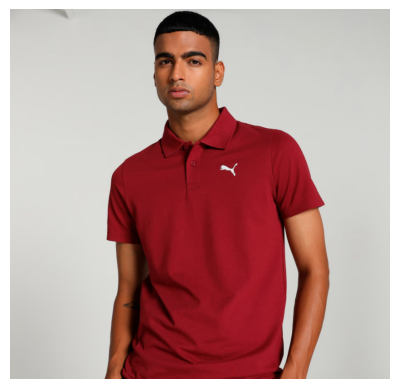

In [9]:
image = Image.open("Screenshot 2026-08-05 212021.png").convert("RGB")

plt.imshow(image)
plt.axis("off")

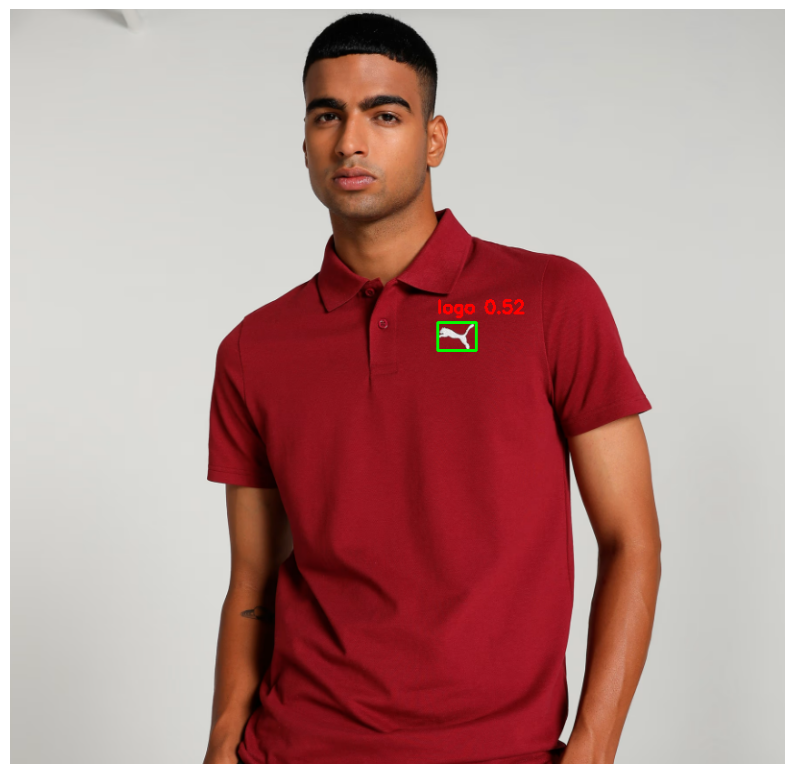

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_np = np.array(image).copy()

boxes = results[0]["boxes"].cpu().numpy()
scores = results[0]["scores"].cpu().numpy()
labels = results[0]["labels"]

for box, score, label in zip(boxes, scores, labels):

    x1, y1, x2, y2 = box.astype(int)

    cv2.rectangle(
        image_np,
        (x1, y1),
        (x2, y2),
        (0,255,0),
        2
    )

    cv2.putText(
        image_np,
        f"{label} {score:.2f}",
        (x1, y1-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255,0,0),
        2
    )

plt.figure(figsize=(10,10))
plt.imshow(image_np)
plt.axis("off")
plt.show()

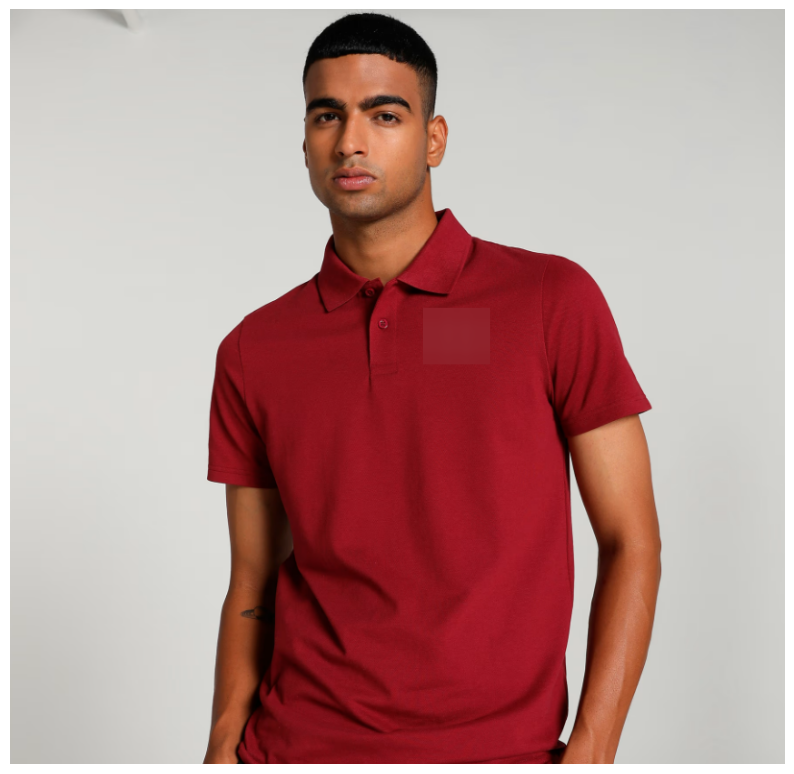

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Convert PIL image to numpy
image_np = np.array(image).copy()

# Loop through all detected logos
for box in results[0]["boxes"]:

    x1, y1, x2, y2 = box.cpu().numpy().astype(int)

    # Add some padding so the entire logo gets covered
    padding = 15

    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(image_np.shape[1], x2 + padding)
    y2 = min(image_np.shape[0], y2 + padding)

    # Crop the logo region
    roi = image_np[y1:y2, x1:x2]

    # Apply Gaussian Blur
    blurred_roi = cv2.GaussianBlur(roi, (151, 151), 80)

    # Replace the region
    image_np[y1:y2, x1:x2] = blurred_roi

# Display
plt.figure(figsize=(10,10))
plt.imshow(image_np)
plt.axis("off")
plt.show()

(-0.5, 999.5, 999.5, -0.5)

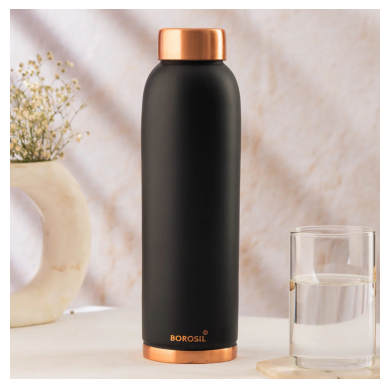

In [19]:
image = Image.open("image copy.png").convert("RGB")

plt.imshow(image)
plt.axis("off")

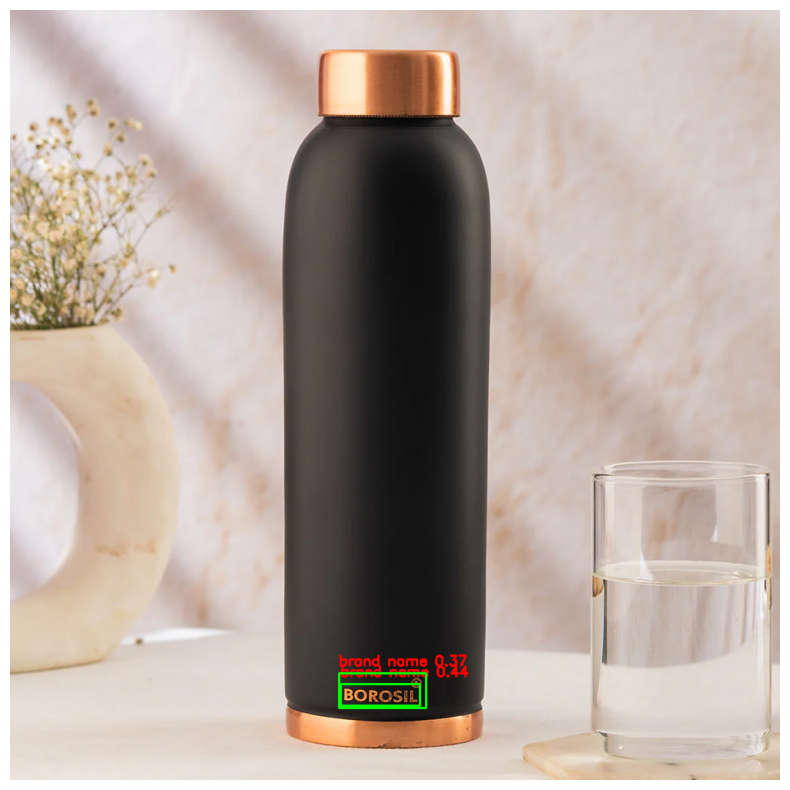

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_np = np.array(image).copy()

boxes = results[0]["boxes"].cpu().numpy()
scores = results[0]["scores"].cpu().numpy()
labels = results[0]["labels"]

for box, score, label in zip(boxes, scores, labels):

    x1, y1, x2, y2 = box.astype(int)

    cv2.rectangle(
        image_np,
        (x1, y1),
        (x2, y2),
        (0,255,0),
        2
    )

    cv2.putText(
        image_np,
        f"{label} {score:.2f}",
        (x1, y1-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255,0,0),
        2
    )

plt.figure(figsize=(10,10))
plt.imshow(image_np)
plt.axis("off")
plt.show()

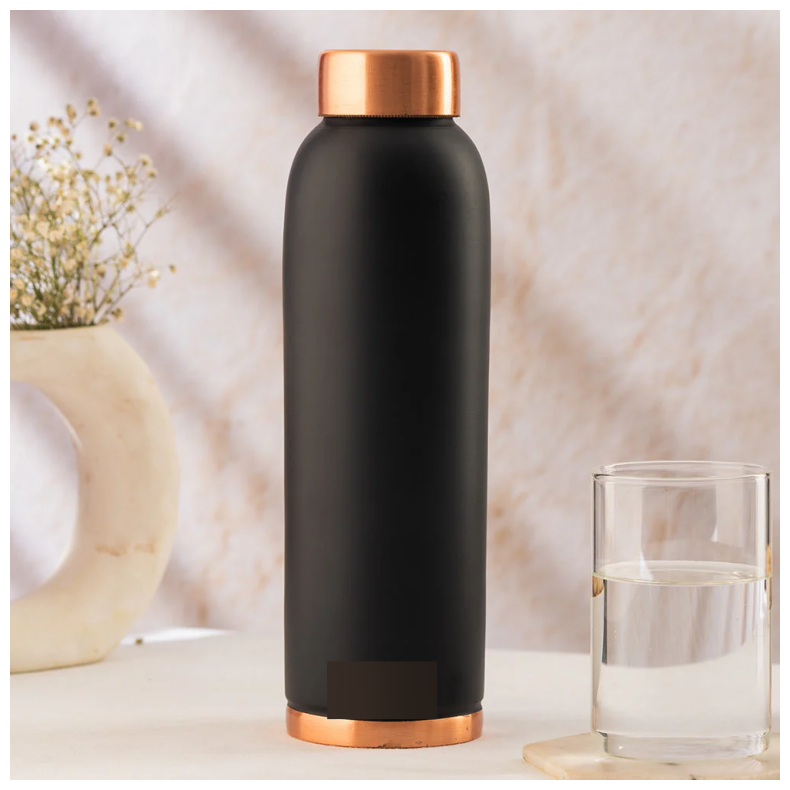

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Convert PIL image to numpy
image_np = np.array(image).copy()

# Loop through all detected logos
for box in results[0]["boxes"]:

    x1, y1, x2, y2 = box.cpu().numpy().astype(int)

    # Add some padding so the entire logo gets covered
    padding = 15

    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(image_np.shape[1], x2 + padding)
    y2 = min(image_np.shape[0], y2 + padding)

    # Crop the logo region
    roi = image_np[y1:y2, x1:x2]

    # Apply Gaussian Blur
    blurred_roi = cv2.GaussianBlur(roi, (151, 151), 80)

    # Replace the region
    image_np[y1:y2, x1:x2] = blurred_roi

# Display
plt.figure(figsize=(10,10))
plt.imshow(image_np)
plt.axis("off")
plt.show()

(-0.5, 499.5, 499.5, -0.5)

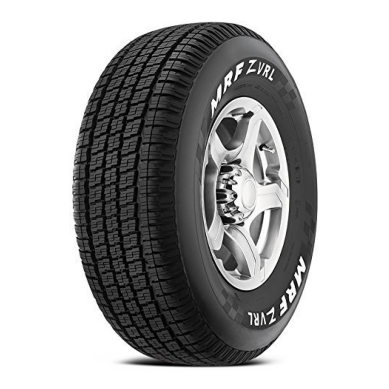

In [36]:
image = Image.open("image.png").convert("RGB")

plt.imshow(image)
plt.axis("off")

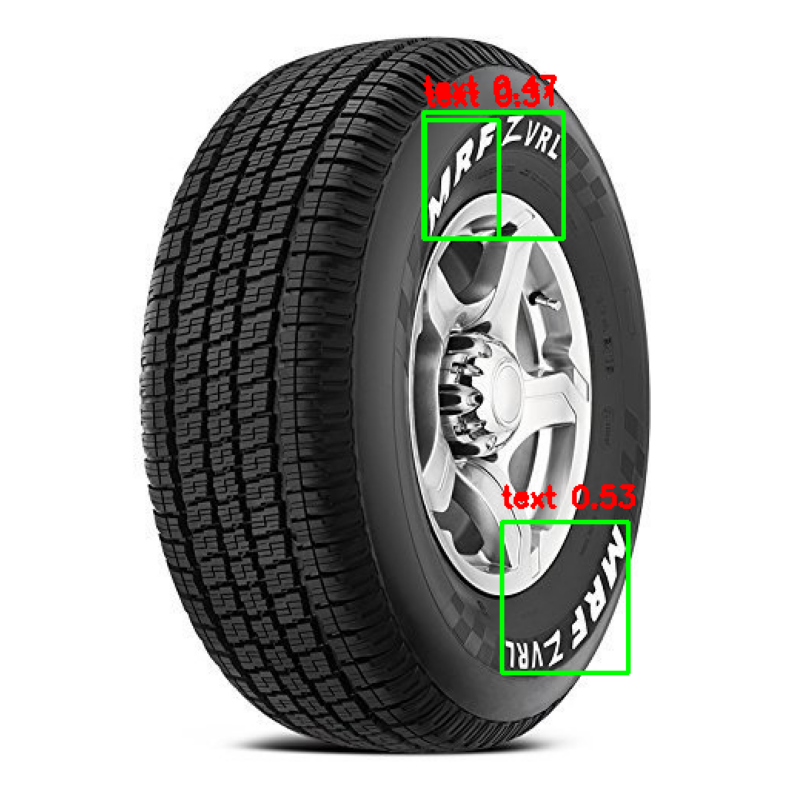

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_np = np.array(image).copy()

boxes = results[0]["boxes"].cpu().numpy()
scores = results[0]["scores"].cpu().numpy()
labels = results[0]["labels"]

for box, score, label in zip(boxes, scores, labels):

    x1, y1, x2, y2 = box.astype(int)

    cv2.rectangle(
        image_np,
        (x1, y1),
        (x2, y2),
        (0,255,0),
        2
    )

    cv2.putText(
        image_np,
        f"{label} {score:.2f}",
        (x1, y1-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255,0,0),
        2
    )

plt.figure(figsize=(10,10))
plt.imshow(image_np)
plt.axis("off")
plt.show()

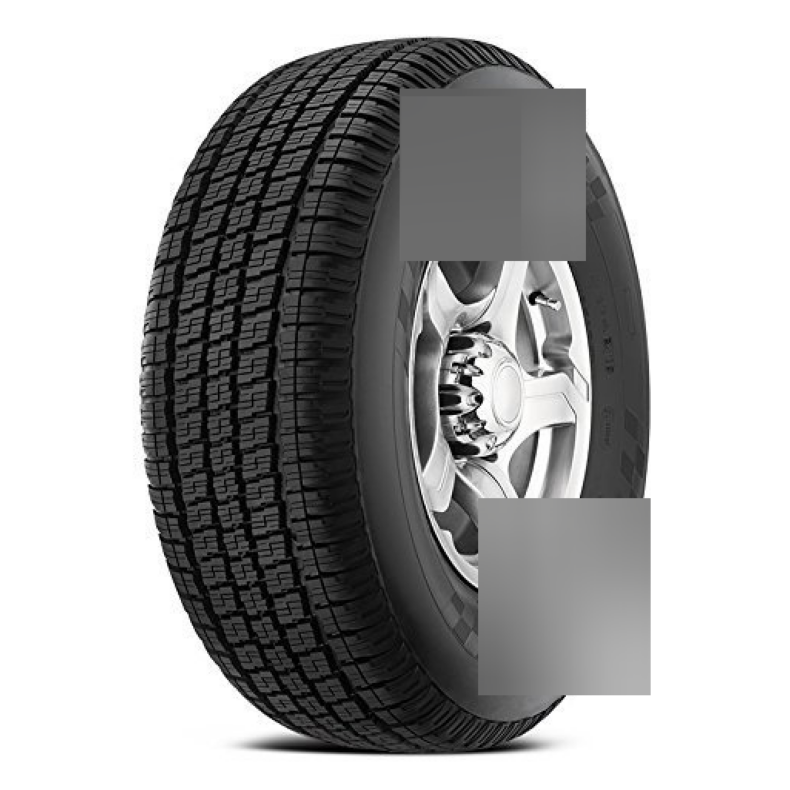

In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Convert PIL image to numpy
image_np = np.array(image).copy()

# Loop through all detected logos
for box in results[0]["boxes"]:

    x1, y1, x2, y2 = box.cpu().numpy().astype(int)

    # Add some padding so the entire logo gets covered
    padding = 15

    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(image_np.shape[1], x2 + padding)
    y2 = min(image_np.shape[0], y2 + padding)

    # Crop the logo region
    roi = image_np[y1:y2, x1:x2]

    # Apply Gaussian Blur
    blurred_roi = cv2.GaussianBlur(roi, (151, 151), 80)

    # Replace the region
    image_np[y1:y2, x1:x2] = blurred_roi

# Display
plt.figure(figsize=(10,10))
plt.imshow(image_np)
plt.axis("off")
plt.show()

(-0.5, 538.5, 567.5, -0.5)

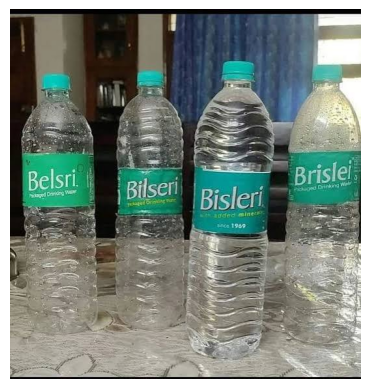

In [39]:
image = Image.open("image copy 2.png").convert("RGB")

plt.imshow(image)
plt.axis("off")

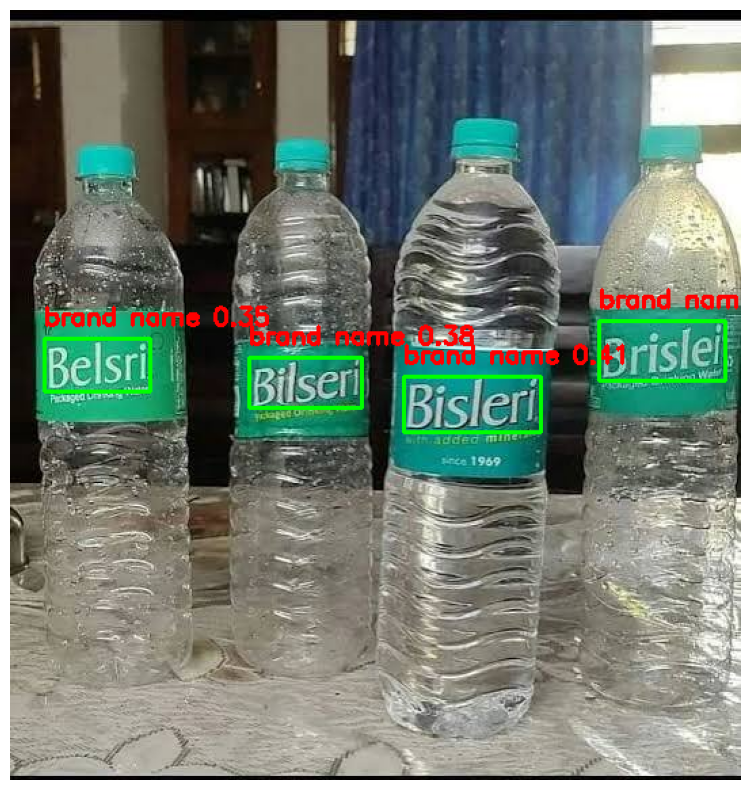

In [46]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_np = np.array(image).copy()

boxes = results[0]["boxes"].cpu().numpy()
scores = results[0]["scores"].cpu().numpy()
labels = results[0]["labels"]

for box, score, label in zip(boxes, scores, labels):

    x1, y1, x2, y2 = box.astype(int)

    cv2.rectangle(
        image_np,
        (x1, y1),
        (x2, y2),
        (0,255,0),
        2
    )

    cv2.putText(
        image_np,
        f"{label} {score:.2f}",
        (x1, y1-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255,0,0),
        2
    )

plt.figure(figsize=(10,10))
plt.imshow(image_np)
plt.axis("off")
plt.show()

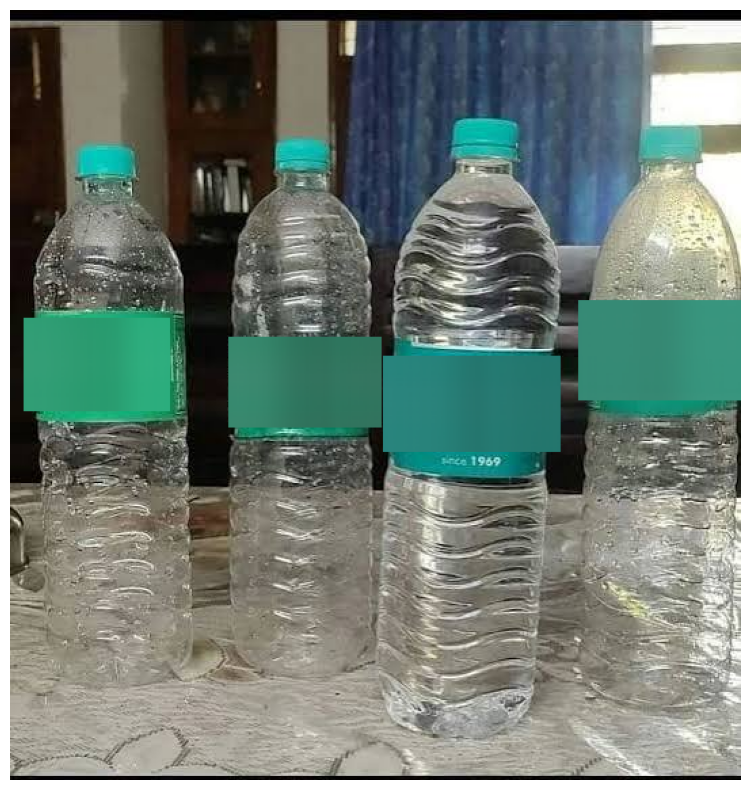

In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Convert PIL image to numpy
image_np = np.array(image).copy()

# Loop through all detected logos
for box in results[0]["boxes"]:

    x1, y1, x2, y2 = box.cpu().numpy().astype(int)

    # Add some padding so the entire logo gets covered
    padding = 15

    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(image_np.shape[1], x2 + padding)
    y2 = min(image_np.shape[0], y2 + padding)

    # Crop the logo region
    roi = image_np[y1:y2, x1:x2]

    # Apply Gaussian Blur
    blurred_roi = cv2.GaussianBlur(roi, (151, 151), 80)

    # Replace the region
    image_np[y1:y2, x1:x2] = blurred_roi

# Display
plt.figure(figsize=(10,10))
plt.imshow(image_np)
plt.axis("off")
plt.show()

---

## 👨‍💻 About Labellerr's Hands-On Learning in Computer Vision

Thank you for exploring this **Labellerr Hands-On Computer Vision Cookbook**! We hope this notebook helped you learn, prototype, and accelerate your vision projects.  
Labellerr provides ready-to-run Jupyter/Colab notebooks for the latest models and real-world use cases in computer vision, AI agents, and data annotation.

---
## 🧑‍🔬 Check Our Popular Youtube Videos

Whether you're a beginner or a practitioner, our hands-on training videos are perfect for learning custom model building, computer vision techniques, and applied AI:

- [How to Fine-Tune YOLO on Custom Dataset](https://www.youtube.com/watch?v=pBLWOe01QXU)  
  Step-by-step guide to fine-tuning YOLO for real-world use—environment setup, annotation, training, validation, and inference.
- [Build a Real-Time Intrusion Detection System with YOLO](https://www.youtube.com/watch?v=kwQeokYDVcE)  
  Create an AI-powered system to detect intruders in real time using YOLO and computer vision.
- [Finding Athlete Speed Using YOLO](https://www.youtube.com/watch?v=txW0CQe_pw0)  
  Estimate real-time speed of athletes for sports analytics.
- [Object Counting Using AI](https://www.youtube.com/watch?v=smsjBBQcIUQ)  
  Learn dataset curation, annotation, and training for robust object counting AI applications.
---

## 🎦 Popular Labellerr YouTube Videos

Level up your skills and see video walkthroughs of these tools and notebooks on the  
[Labellerr YouTube Channel](https://www.youtube.com/@Labellerr/videos):

- [How I Fixed My Biggest Annotation Nightmare with Labellerr](https://www.youtube.com/watch?v=hlcFdiuz_HI) – Solving complex annotation for ML engineers.
- [Explore Your Dataset with Labellerr's AI](https://www.youtube.com/watch?v=LdbRXYWVyN0) – Auto-tagging, object counting, image descriptions, and dataset exploration.
- [Boost AI Image Annotation 10X with Labellerr's CLIP Mode](https://www.youtube.com/watch?v=pY_o4EvYMz8) – Refine annotations with precision using CLIP mode.
- [Boost Data Annotation Accuracy and Efficiency with Active Learning](https://www.youtube.com/watch?v=lAYu-ewIhTE) – Speed up your annotation workflow using Active Learning.

> 👉 **Subscribe** for Labellerr's deep learning, annotation, and AI tutorials, or watch videos directly alongside notebooks!

---

## 🤝 Stay Connected

- **Website:** [https://www.labellerr.com/](https://www.labellerr.com/)
- **Blog:** [https://www.labellerr.com/blog/](https://www.labellerr.com/blog/)
- **GitHub:** [Labellerr/Hands-On-Learning-in-Computer-Vision](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)
- **LinkedIn:** [Labellerr](https://in.linkedin.com/company/labellerr)
- **Twitter/X:** [@Labellerr1](https://x.com/Labellerr1)

*Happy learning and building with Labellerr!*
